# Forward FTLE over Cabo Verde from CMEMS currents

A real, end-to-end LCS example: seed a grid, advect it through **CMEMS**
surface currents with **Parcels v4**, ingest the advected positions, and map
the forward finite-time Lyapunov exponent (FTLE) $\Lambda = \frac{1}{|T|}
\log\sqrt{\lambda_{\max}(C)}$ (Haller 2015,
[doi:10.1146/annurev-fluid-010313-141322](https://doi.org/10.1146/annurev-fluid-010313-141322)).
Ridges of high forward FTLE are repelling Lagrangian coherent structures.

We run it twice -- once with the **neighbor** stencil (gradient differenced
across the seed grid) and once with the **auxiliary** stencil (a four-arm
micro-stencil decoupled from the grid) -- to compare the two `lcs_parcels`
flow maps on the same flow. Release time, window, grid resolution and domain
are all set in the **Parameters** cell below.

Needs the `examples` pixi environment (Parcels v4 + CMEMS access): run with
`pixi run -e examples jupyter ...`, and CMEMS credentials configured for
`copernicusmarine`.

In [1]:
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import copernicusmarine as cm
from parcels import FieldSet, ParticleSet, Particle, StatusCode
from parcels.kernels import AdvectionRK4
from parcels.convert import copernicusmarine_to_sgrid

from lcs_parcels import NeighborSeed, AuxiliarySeed

/Users/wrath/src/github.com/geomar-od-lagrange/lcs_parcels/.pixi/envs/examples/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_42323/3220655132.py:8: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  from parcels import FieldSet, ParticleSet, Particle, StatusCode


## Parameters

Everything tunable lives in one papermill-style `parameters` cell. The main
knob is `resolution_deg` (the seed-grid spacing); the rest set the release
window, the stencil, and the domain.

In [2]:
# Release time and integration window.
t0 = "2025-08-01"           # release date (UTC midnight)
window_days = 10            # integration length, days; > 0 = forward (repelling LCS)

# Seed grid and stencils.
resolution_deg = 1 / 25     # release-grid spacing, degrees
aux_separation_m = 3000.0   # auxiliary four-arm stencil half-length, metres

# Domain, degrees.
core_lon = (-25.4, -22.6)   # Cabo Verde archipelago bounding box
core_lat = (14.8, 17.2)
seed_margin_frac = 1.0      # grow the core box by this fraction per side (1.0 = 100 %)
data_lon = (-30.5, -17.5)   # current-field domain = seed box + advection margin
data_lat = (10.0, 22.0)

# CMEMS currents.
dataset_id = "cmems_mod_glo_phy_anfc_0.083deg_PT1H-m"
advection_dt_hours = 1      # RK4 time step

## Domain

The seed box is the archipelago core grown by `seed_margin_frac` on every side
(100 % by default), so the release grid frames the islands with ample room.
The current field spans the larger `data_lon`/`data_lat` box -- the seed box
plus an advection margin -- so particles stay inside the fields for the whole
window.

In [3]:
t0 = np.datetime64(t0)
T = np.timedelta64(window_days, "D")   # signed window; sign(T) sets the direction
t1 = t0 + T


def grow(bounds, frac):
    """Grow a (lo, hi) interval by `frac` of its extent on each side."""
    lo, hi = bounds
    mid, half = 0.5 * (lo + hi), 0.5 * (hi - lo)
    return (mid - half * (1 + frac), mid + half * (1 + frac))


seed_lon = grow(core_lon, seed_margin_frac)
seed_lat = grow(core_lat, seed_margin_frac)
print("seed box:  lon", tuple(round(v, 2) for v in seed_lon),
      " lat", tuple(round(v, 2) for v in seed_lat))

seed box:  lon (-26.8, -21.2)  lat (13.6, 18.4)


## Currents: CMEMS hourly surface velocity

Global Ocean Physics Analysis-Forecast, hourly surface `uo`/`vo`
(`cmems_mod_glo_phy_anfc_0.083deg_PT1H-m`), subset to the data domain with one
day of padding on each side of the window. The subset is cached locally so
re-runs don't re-download.

In [4]:
cache = Path("data/cabo_verde_currents_hourly.nc")
cache.parent.mkdir(exist_ok=True)
pad = np.timedelta64(1, "D")

if cache.exists():
    ds = xr.open_dataset(cache)
else:
    ds = cm.open_dataset(
        dataset_id=dataset_id,
        variables=["uo", "vo"],
        minimum_longitude=data_lon[0], maximum_longitude=data_lon[1],
        minimum_latitude=data_lat[0], maximum_latitude=data_lat[1],
        minimum_depth=0.0, maximum_depth=1.0,
        start_datetime=str((t0 - pad).astype("datetime64[D]")),
        end_datetime=str((t1 + pad).astype("datetime64[D]")),
    ).load()
    ds.to_netcdf(cache)

ds

<xarray.Dataset> Size: 53MB
Dimensions:    (time: 289, depth: 1, latitude: 145, longitude: 157)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2025-07-31 ... 2025-08-12
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 580B 10.0 10.08 10.17 ... 21.83 21.92 22.0
  * longitude  (longitude) float32 628B -30.5 -30.42 -30.33 ... -17.58 -17.5
Data variables:
    uo         (time, depth, latitude, longitude) float32 26MB ...
    vo         (time, depth, latitude, longitude) float32 26MB ...
Attributes:
    Conventions:               CF-1.8
    area:                      Global
    contact:                   https://marine.copernicus.eu/contact
    credit:                    E.U. Copernicus Marine Service Information (CM...
    institution:               Mercator Ocean International
    licence:                   http://marine.copernicus.eu/services-portfolio...
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    references:                http://marine.copernicus.eu
    source:                    MOI GLO12
    title:                     hourly mean fields from Global Ocean Physics A...
    copernicusmarine_version:  2.4.1

## Build the Parcels v4 field set

`copernicusmarine_to_sgrid` renames `uo`/`vo` to `U`/`V` and tags the CMEMS
A-grid with SGRID metadata; `from_sgrid_conventions` wraps it as a spherical
`FieldSet`. We keep the single surface depth for the 2-D advection.

In [5]:
sgrid = copernicusmarine_to_sgrid(fields={"U": ds["uo"], "V": ds["vo"]})
fieldset = FieldSet.from_sgrid_conventions(sgrid, mesh="spherical")
z_surface = float(ds["depth"].values[0])
z_surface

0.49402499198913574

## Advection driver

One helper advects any `lcs_parcels` seed: emit the flat particle set, run RK4
forward for $T$ at the configured step, and ingest the final positions back
into a `FlowMap`. A recovery kernel turns particles that leave the domain or
hit land into `NaN` **in place** (Parcels would otherwise abort the run), so
losses propagate as `NaN` through the FTLE aligned to the seed grid.

In [6]:
def set_lost_to_nan(particles, fieldset):
    """Freeze out-of-bounds / land particles at NaN instead of aborting."""
    lost = particles.state >= StatusCode.Error
    particles.x = np.where(lost, np.nan, particles.x)
    particles.y = np.where(lost, np.nan, particles.y)
    particles.state = np.where(lost, StatusCode.EndofLoop, particles.state)


def advect(seed):
    lon, lat = seed.to_parcels_pset()
    lon = np.asarray(lon, dtype=float)
    lat = np.asarray(lat, dtype=float)
    pset = ParticleSet(
        fieldset, pclass=Particle,
        x=lon, y=lat, z=np.full(lon.size, z_surface), t=np.full(lon.size, t0),
    )
    pset.execute(
        [AdvectionRK4, set_lost_to_nan],
        dt=np.timedelta64(advection_dt_hours, "h"), runtime=T, verbose_progress=False,
    )
    fin_lon, fin_lat = np.asarray(pset.x, dtype=float), np.asarray(pset.y, dtype=float)
    lost = int(np.isnan(fin_lon).sum())
    print(f"advected {lon.size} particles, {lost} lost ({100 * lost / lon.size:.1f}%)")
    return seed.pset_to_flowmap(fin_lon, fin_lat, t0=t0, t1=t1)

## Seed grid

A rectilinear grid at `resolution_deg` over the seed box, shared by both
stencils.

In [7]:
lon_axis = np.arange(seed_lon[0], seed_lon[1] + 1e-9, resolution_deg)
lat_axis = np.arange(seed_lat[0], seed_lat[1] + 1e-9, resolution_deg)
print(f"{lon_axis.size} x {lat_axis.size} = {lon_axis.size * lat_axis.size} grid points"
      f" at {resolution_deg:.4g} deg")

141 x 121 = 17061 grid points at 0.04 deg


## Neighbor stencil

`NeighborSeed` releases one particle per grid point; the deformation gradient
is differenced against neighbouring grid points, so its resolution is tied to
the seed spacing.

In [8]:
fm_neighbor = advect(NeighborSeed.from_axes(lon_axis, lat_axis))

advected 17061 particles, 1349 lost (7.9%)


## Auxiliary stencil

`AuxiliarySeed` places a four-arm micro-stencil (arm half-length
`aux_separation_m`) around each grid point, so the gradient step is decoupled
from the grid: four times as many particles, but a local, boundary-safe
gradient.

In [9]:
fm_auxiliary = advect(AuxiliarySeed.from_axes(lon_axis, lat_axis, aux_separation_m=aux_separation_m))

advected 68244 particles, 5350 lost (7.8%)


## FTLE

`FlowMap.ftle()` returns the field in $1/\mathrm{s}$; we report $1/\mathrm{day}$.

In [10]:
per_day = 86400.0
ftle_neighbor = (fm_neighbor.ftle() * per_day).rename("FTLE")
ftle_auxiliary = (fm_auxiliary.ftle() * per_day).rename("FTLE")

for name, f in [("neighbor", ftle_neighbor), ("auxiliary", ftle_auxiliary)]:
    print(f"{name:9s} FTLE [1/day]:  mean {float(f.mean()):.3f}   "
          f"max {float(f.max()):.3f}   valid {int(f.notnull().sum())}")

neighbor  FTLE [1/day]:  mean 0.107   max 0.339   valid 14544
auxiliary FTLE [1/day]:  mean 0.107   max 0.366   valid 15287


## Maps

Forward FTLE for both stencils on a shared colour scale. Land (from the CMEMS
surface mask) is drawn grey; the islands also appear as `NaN` gaps where
particles were lost.

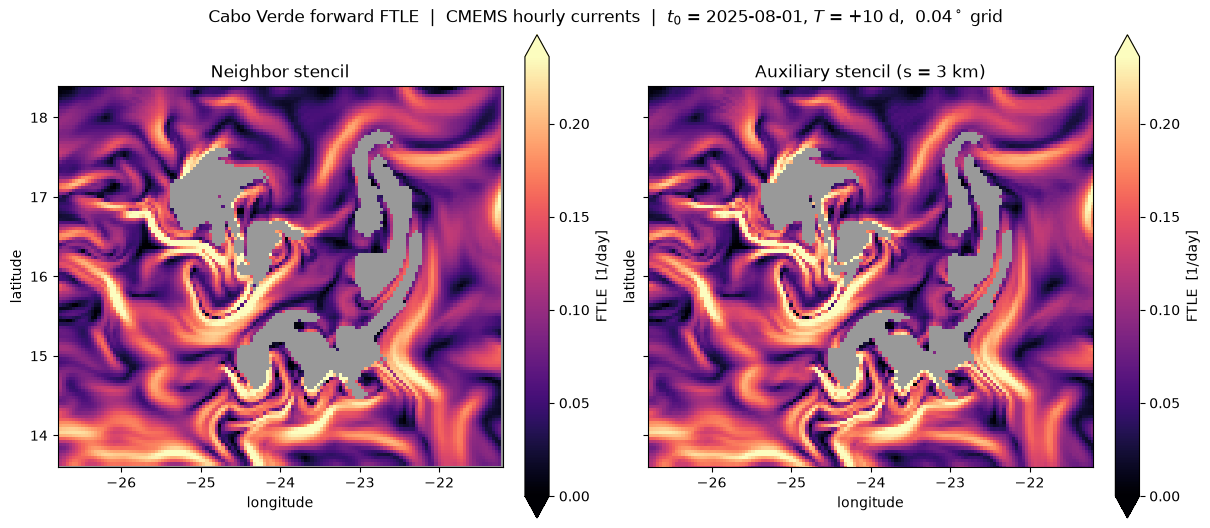

In [11]:
land = ds["uo"].isel(time=0, depth=0).isnull()
vmax = float(np.nanpercentile(
    np.concatenate([ftle_neighbor.values.ravel(), ftle_auxiliary.values.ravel()]), 98))

fig, axs = plt.subplots(1, 2, figsize=(12, 5.2), constrained_layout=True,
                        sharex=True, sharey=True)
for ax, f, xc, yc, title in [
    (axs[0], ftle_neighbor, "lon_0", "lat_0", "Neighbor stencil"),
    (axs[1], ftle_auxiliary, "lon_c", "lat_c",
     f"Auxiliary stencil (s = {aux_separation_m / 1000:g} km)"),
]:
    land.plot.contourf(x="longitude", y="latitude", ax=ax, levels=[0.5, 1.5],
                       colors="0.6", add_colorbar=False)
    f.plot.pcolormesh(x=xc, y=yc, ax=ax, cmap="magma", vmin=0.0, vmax=vmax,
                      cbar_kwargs={"label": "FTLE  [1/day]"})
    ax.set(title=title, xlabel="longitude", ylabel="latitude",
           xlim=seed_lon, ylim=seed_lat)
    ax.set_aspect("equal")
fig.suptitle(f"Cabo Verde forward FTLE  |  CMEMS hourly currents  |  "
             f"$t_0$ = {np.datetime_as_string(t0, unit='D')}, "
             f"$T$ = +{window_days} d,  {resolution_deg:.4g}$^\\circ$ grid")
plt.show()

Both stencils recover the same web of forward-FTLE ridges -- repelling LCS
that organise the near-surface transport around the islands -- at comparable
magnitudes (see the printed means above). The neighbor stencil ties its
gradient step to the seed spacing, while the auxiliary stencil uses its own
arm length; the grey islands and the `NaN` gaps mark particles that grounded
or left the domain.